In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
from pathlib import Path
import seaborn as sns

# 定义自定义顺序
custom_order = ["FedAGSA", "PyramidFL", "FedDocs", "FedLC", "FedAvg"]

# 创建排序键函数
def custom_sort(item):
    # 对于列表中的项目，返回其索引
    for i, prefix in enumerate(custom_order):
        if item.startswith(prefix):
            return i
    # 对于不在列表中的项目，返回一个较大的数，使它们排在最后
    return len(custom_order)

def analyze_client_selection(main_dir, time_info_file, time_bins=None, max_epoch=None, save_plots=True):
    """
    分析联邦学习算法中客户端选择情况，并按时间区间进行统计
    
    参数:
        main_dir (str): 主实验目录路径，包含各个算法子目录
        time_info_file (str): 客户端时间信息文件路径
        time_bins (list): 时间区间列表，例如 [0, 5, 10, 15, 20]，如果为None则自动生成
        max_epoch (int): 要分析的最大epoch数，如果为None则分析所有数据
        save_plots (bool): 是否保存生成的图表
        
    返回:
        dict: 包含各算法分析结果的字典
    """
    print(f"正在分析目录: {main_dir}")
    print(f"使用客户端时间信息文件: {time_info_file}")
    
    # 读取客户端时间信息
    time_info = pd.read_csv(time_info_file)
    time_info = time_info.set_index('client_id')
    
    # 如果未指定时间区间，则自动生成
    if time_bins is None:
        # 根据时间数据的分布自动生成区间
        min_time = time_info['time'].min()
        max_time = time_info['time'].max()
        # 生成5个均匀的区间
        time_bins = np.linspace(min_time, max_time, 6).round(1)
    
    print(f"使用时间区间: {time_bins}")
    
    # 存储分析结果
    results = {}
    
    # 获取算法目录列表并按自定义顺序排序
    algo_dirs = [d for d in os.listdir(main_dir) if os.path.isdir(os.path.join(main_dir, d))]
    algo_dirs.sort(key=custom_sort)
    
    for algo_dir in algo_dirs:
        full_path = os.path.join(main_dir, algo_dir)
        csv_path = os.path.join(full_path, 'epoch_results_with_cumtime.csv')
        
        # 检查CSV文件是否存在
        if not os.path.exists(csv_path):
            print(f"跳过 {algo_dir}: 未找到 epoch_results_with_cumtime.csv 文件")
            continue
        
        try:
            # 读取CSV文件
            df = pd.read_csv(csv_path)
            
            # 确保CSV包含所需列
            if 'selected_clients' not in df.columns:
                print(f"警告: {csv_path} 缺少 selected_clients 列")
                continue
                
            # 限制最大epoch数
            if max_epoch is not None:
                df = df[df['epoch'] <= max_epoch]
                
            # 将字符串形式的列表转换为实际列表
            df['selected_clients'] = df['selected_clients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
            
            # 统计每个客户端被选择的次数
            client_selections = {}
            for idx, row in df.iterrows():
                selected = row['selected_clients']
                for client in selected:
                    client_selections[client] = client_selections.get(client, 0) + 1
            
            # 创建包含选择次数和时间的DataFrame
            analysis_df = pd.DataFrame({
                'client_id': list(client_selections.keys()),
                'selections': list(client_selections.values())
            })
            
            # 添加时间信息
            analysis_df['time'] = analysis_df['client_id'].map(lambda x: time_info.loc[x, 'time'] if x in time_info.index else np.nan)
            
            # 根据时间区间进行分组统计
            analysis_df['time_bin'] = pd.cut(analysis_df['time'], bins=time_bins)
            bin_stats = analysis_df.groupby('time_bin')['selections'].agg(['mean', 'count', 'std']).round(2)
            
            # 存储算法的分析结果
            results[algo_dir] = {
                'client_selections': client_selections,
                'bin_stats': bin_stats,
                'analysis_df': analysis_df
            }
            
            print(f"成功分析 {algo_dir} 的数据")
            print(f"时间区间统计结果:")
            print(bin_stats)
            
        except Exception as e:
            print(f"处理 {csv_path} 时出错: {e}")
    
    # 如果需要保存图表
    if save_plots and results:
        save_selection_plots(results, main_dir, time_bins)
    
    return results

def save_selection_plots(results, main_dir, time_bins):
    """
    生成并保存客户端选择分析的图表
    
    参数:
        results (dict): analyze_client_selection 函数返回的结果
        main_dir (str): 主实验目录路径
        time_bins (list): 时间区间列表
    """
    # 生成boxplot图表
    plt.figure(figsize=(12, 8))
    
    # 为每个算法准备数据
    plot_data = []
    labels = []
    
    for algo_name, result in results.items():
        df = result['analysis_df']
        plot_data.append(df['selections'])
        algo_short_name = algo_name.split('-')[0]  # 获取算法简短名称
        labels.append(algo_short_name)
    
    # 创建箱线图
    plt.boxplot(plot_data, labels=labels)
    plt.title('客户端选择次数分布', fontsize=16)
    plt.ylabel('选择次数', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # 保存图表
    boxplot_path = os.path.join(main_dir, f'{Path(main_dir).name}_boxplot.png')
    plt.savefig(boxplot_path, dpi=300)
    print(f"保存箱线图: {boxplot_path}")
    
    # 生成轮次时间分布图
    plt.figure(figsize=(12, 8))
    
    # 为每个算法创建数据
    for algo_name, result in results.items():
        df = result['analysis_df']
        algo_short_name = algo_name.split('-')[0]
        
        # 将时间和选择次数相关联
        plt.scatter(df['time'], df['selections'], alpha=0.6, label=algo_short_name)
    
    plt.title('客户端时间与选择次数关系', fontsize=16)
    plt.xlabel('客户端时间', fontsize=14)
    plt.ylabel('选择次数', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # 保存图表
    scatter_path = os.path.join(main_dir, f'{Path(main_dir).name}_roundtime_boxplot.png')
    plt.savefig(scatter_path, dpi=300)
    print(f"保存散点图: {scatter_path}")
    
    # 生成按时间区间的选择次数柱状图
    plt.figure(figsize=(14, 8))
    
    # 计算时间区间标签
    bin_labels = [f"{time_bins[i]}-{time_bins[i+1]}" for i in range(len(time_bins)-1)]
    
    # 为每个算法创建柱状图组
    bar_width = 0.15
    offsets = np.arange(-(len(results) - 1) / 2 * bar_width, (len(results) + 1) / 2 * bar_width, bar_width)
    
    # 为每个时间区间创建一组柱状图
    for i, (algo_name, result) in enumerate(results.items()):
        bin_stats = result['bin_stats']
        means = bin_stats['mean'].values
        
        # 确保数据长度与区间标签一致
        if len(means) < len(bin_labels):
            means = np.pad(means, (0, len(bin_labels) - len(means)), 'constant', constant_values=0)
        
        algo_short_name = algo_name.split('-')[0]
        x = np.arange(len(bin_labels))
        plt.bar(x + offsets[i], means, width=bar_width, label=algo_short_name, alpha=0.7)
    
    plt.title('各时间区间客户端平均选择次数', fontsize=16)
    plt.xlabel('客户端时间区间', fontsize=14)
    plt.ylabel('平均选择次数', fontsize=14)
    plt.xticks(range(len(bin_labels)), bin_labels, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # 保存图表
    barplot_path = os.path.join(main_dir, f'{Path(main_dir).name}_relative_roundtime_boxplot.png')
    plt.savefig(barplot_path, dpi=300)
    print(f"保存柱状图: {barplot_path}")
    
    # 生成标准化后的选择次数柱状图
    plt.figure(figsize=(14, 8))
    
    # 为每个算法创建柱状图组
    for i, (algo_name, result) in enumerate(results.items()):
        bin_stats = result['bin_stats']
        means = bin_stats['mean'].values
        counts = bin_stats['count'].values
        
        # 计算总体平均值用于归一化
        total_avg = sum(means * counts) / sum(counts) if sum(counts) > 0 else 1
        
        # 归一化数据
        normalized_means = means / total_avg if total_avg > 0 else means
        
        # 确保数据长度与区间标签一致
        if len(normalized_means) < len(bin_labels):
            normalized_means = np.pad(normalized_means, (0, len(bin_labels) - len(normalized_means)), 'constant', constant_values=0)
        
        algo_short_name = algo_name.split('-')[0]
        x = np.arange(len(bin_labels))
        plt.bar(x + offsets[i], normalized_means, width=bar_width, label=algo_short_name, alpha=0.7)
    
    plt.title('各时间区间客户端选择次数（归一化）', fontsize=16)
    plt.xlabel('客户端时间区间', fontsize=14)
    plt.ylabel('归一化选择次数', fontsize=14)
    plt.xticks(range(len(bin_labels)), bin_labels, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.legend(fontsize=12)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)  # 添加参考线
    plt.tight_layout()
    
    # 保存图表
    norm_barplot_path = os.path.join(main_dir, f'{Path(main_dir).name}_normalized_roundtime_boxplot.png')
    plt.savefig(norm_barplot_path, dpi=300)
    print(f"保存归一化柱状图: {norm_barplot_path}")

# # 示例使用方法
# if __name__ == "__main__":
#     # 不直接执行，而是作为库导入使用
#     pass

正在分析目录: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1
使用客户端时间信息文件: /home/ypguo/async-FL/src/clients_info/resnet18/clients_info_2class_resnet_delaymodel.csv
使用时间区间: [ 5.5 10.  14.6 19.1 23.6 28.1]
成功分析 FedAGSA-resnet-dir0.1-tg65-lm0.01-sorted 的数据
时间区间统计结果:
               mean  count   std
time_bin                        
(5.5, 10.0]   30.56     16  1.21
(10.0, 14.6]  29.94     33  3.65
(14.6, 19.1]  32.88     24  0.61
(19.1, 23.6]  31.11     18  3.18
(23.6, 28.1]  19.00      8  0.00
成功分析 PyramidFL-resnet-dir0.1-plus 的数据
时间区间统计结果:
               mean  count    std
time_bin                         
(5.5, 10.0]   30.50     16  21.44
(10.0, 14.6]  27.79     33  18.55
(14.6, 19.1]  28.71     24  20.26
(19.1, 23.6]  29.28     18  22.52
(23.6, 28.1]  37.50      8  17.11
成功分析 FedDocs-resnet-dir0.1-alpha0.66 的数据
时间区间统计结果:
               mean  count    std
time_bin                         
(5.5, 10.0]   39.31     16  43.30
(10.0, 14.6]  51.39     33  52.02
(14.6, 19.1]  46.29     24  47.42

/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25321 (\N{CJK UNIFIED IDEOGRAPH-62E9}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from

保存箱线图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1/Exp2025-Cifar10-lr0.5-Dir0.1_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 25321 (\N{CJK UNIFIED IDEOGRAPH-62E9}) missing from

保存散点图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1/Exp2025-Cifar10-lr0.5-Dir0.1_roundtime_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from

保存柱状图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1/Exp2025-Cifar10-lr0.5-Dir0.1_relative_roundtime_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from

保存归一化柱状图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1/Exp2025-Cifar10-lr0.5-Dir0.1_normalized_roundtime_boxplot.png

==== 各算法客户端选择统计 ====

算法: FedAGSA-resnet-dir0.1-tg65-lm0.01-sorted
时间区间统计:
               mean  count   std
time_bin                        
(5.5, 10.0]   30.56     16  1.21
(10.0, 14.6]  29.94     33  3.65
(14.6, 19.1]  32.88     24  0.61
(19.1, 23.6]  31.11     18  3.18
(23.6, 28.1]  19.00      8  0.00
被选中的独立客户端数: 100
客户端总选择次数: 2997
平均每个客户端被选择次数: 29.97

算法: PyramidFL-resnet-dir0.1-plus
时间区间统计:
               mean  count    std
time_bin                         
(5.5, 10.0]   30.50     16  21.44
(10.0, 14.6]  27.79     33  18.55
(14.6, 19.1]  28.71     24  20.26
(19.1, 23.6]  29.28     18  22.52
(23.6, 28.1]  37.50      8  17.11
被选中的独立客户端数: 100
客户端总选择次数: 2930
平均每个客户端被选择次数: 29.30

算法: FedDocs-resnet-dir0.1-alpha0.66
时间区间统计:
               mean  count    std
time_bin                         
(5.5, 10.0]   39.31     16  43.30
(10.0, 14.6]  51.39     33  52.02
(14.6

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25321 (\N{CJK UNIFIED I

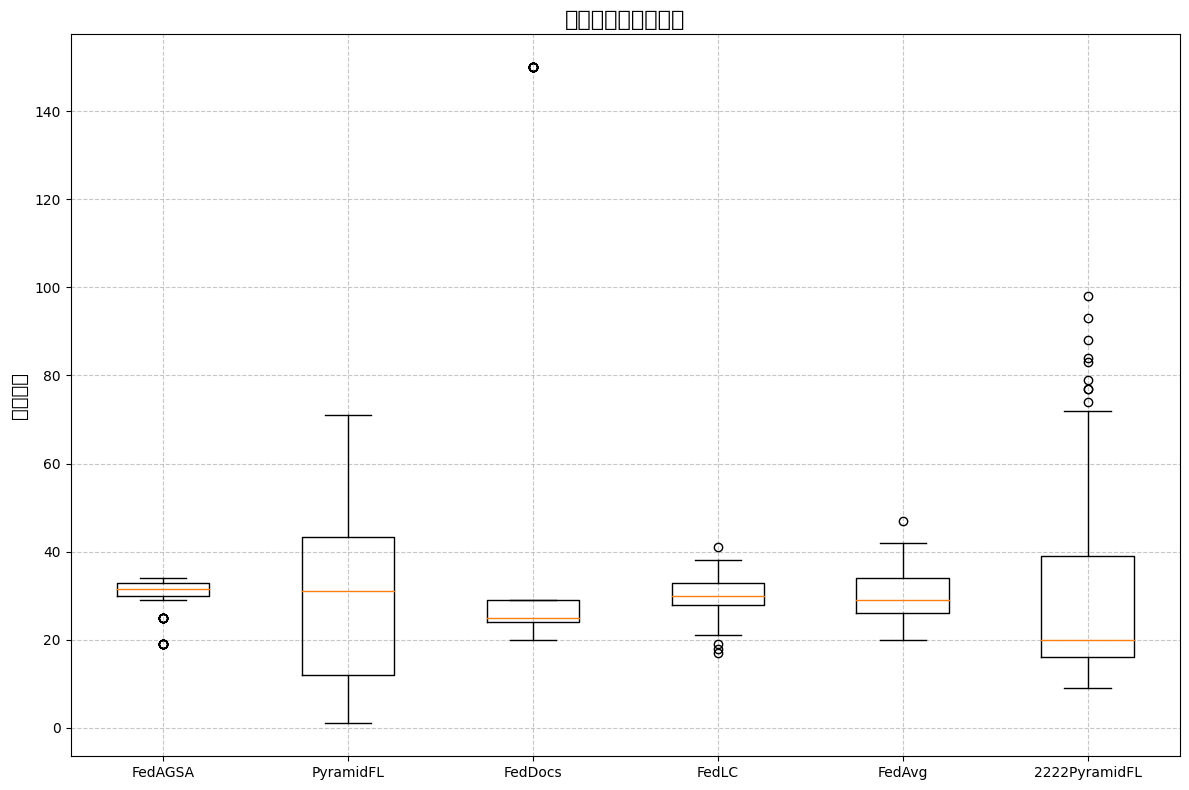

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31995 (\N{CJK UNIFIED I

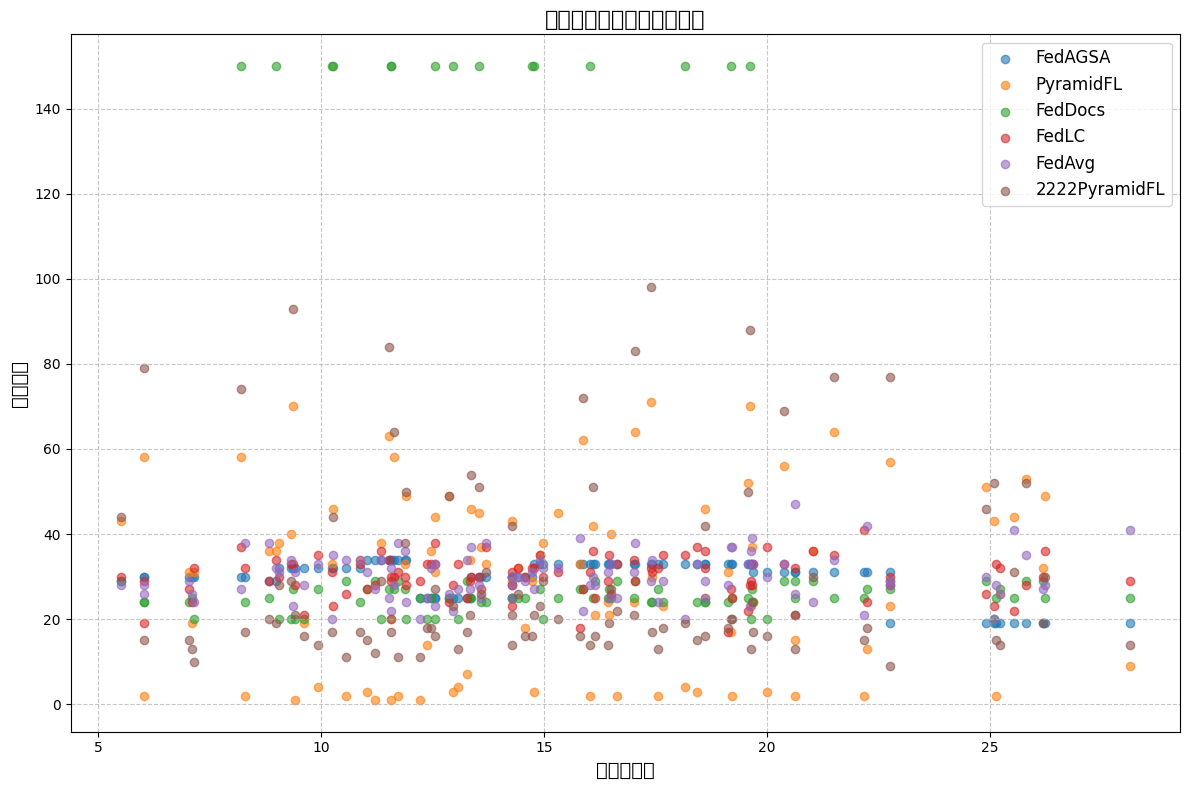

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


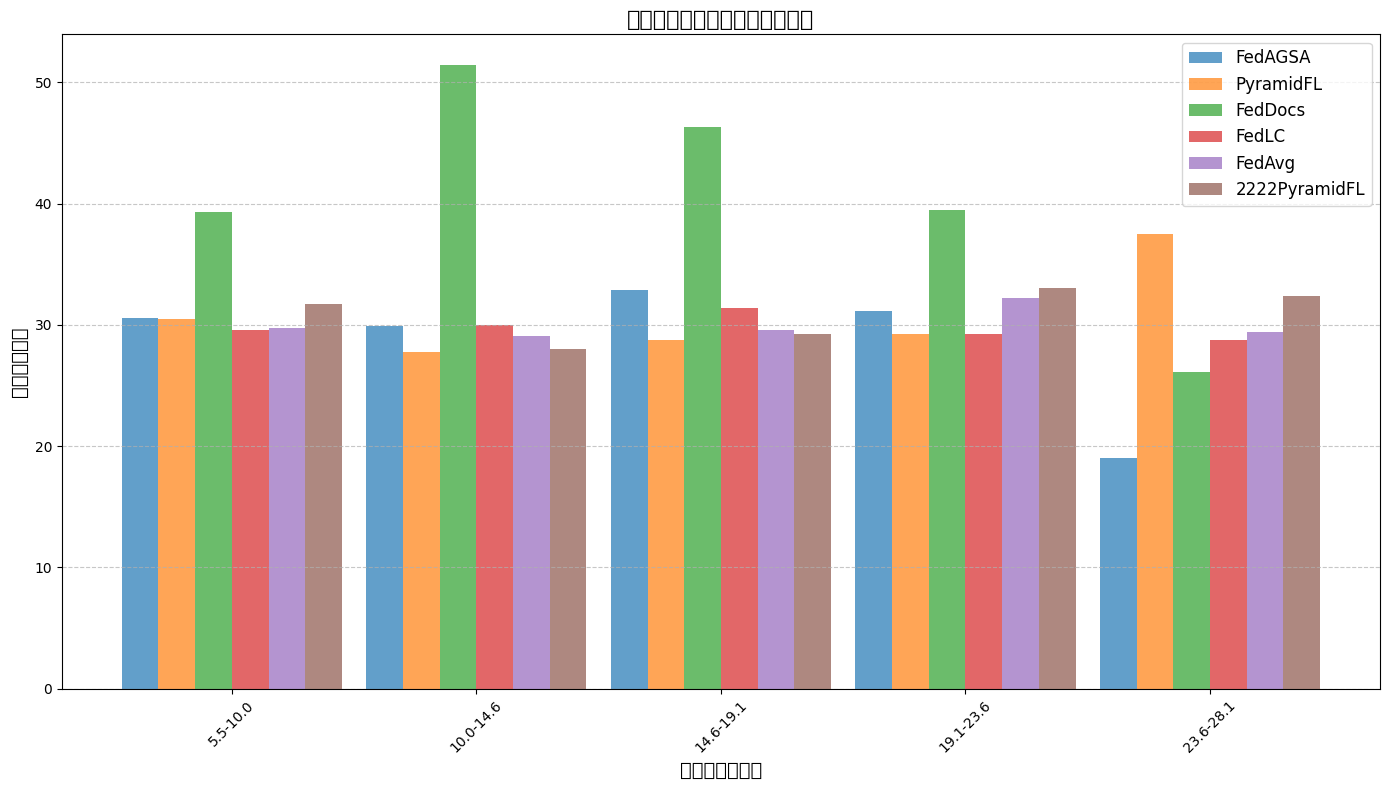

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65289 (\N{FULLWIDTH RIG

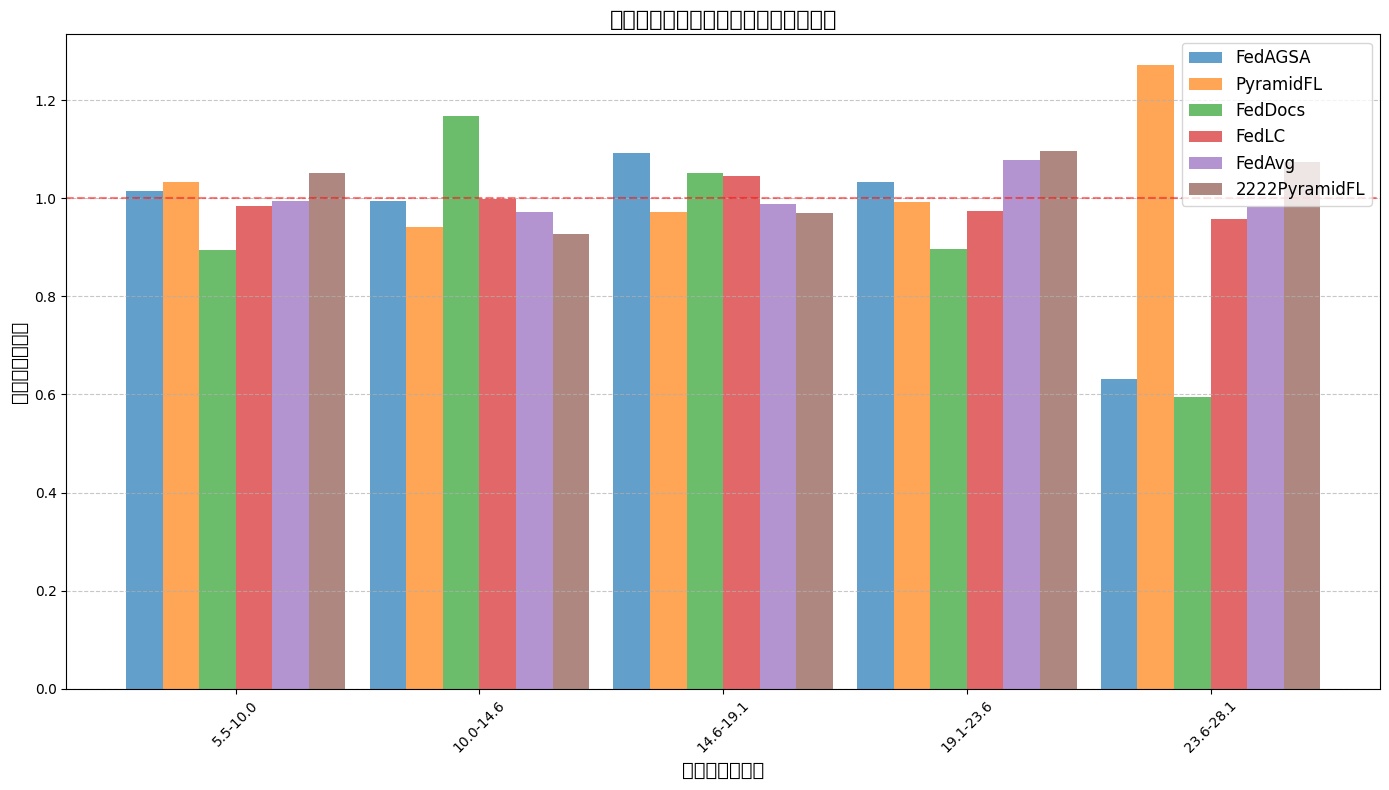

In [2]:
import os
# from analyze_client_selection import analyze_client_selection

def main():
    # 主实验目录路径
    main_dir = "/home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.1"
    
    # 客户端时间信息文件路径
    time_info_file = "/home/ypguo/async-FL/src/clients_info/resnet18/clients_info_2class_resnet_delaymodel.csv"
    
    # 自定义时间区间（可以根据需要修改）
    # 如果不指定，将自动根据数据生成区间
    # time_bins = [0, 3, 6, 9, 12]
    
    # 限制分析的最大epoch数（可选）
    max_epoch = 300
    
    # 执行分析
    results = analyze_client_selection(
        main_dir=main_dir,
        time_info_file=time_info_file,
        # time_bins=time_bins,
        max_epoch=max_epoch,
        save_plots=True
    )
    
    # 输出每个算法的统计信息
    print("\n==== 各算法客户端选择统计 ====")
    for algo_name, result in results.items():
        print(f"\n算法: {algo_name}")
        print("时间区间统计:")
        print(result['bin_stats'])
        
        # 输出额外统计信息
        total_selections = sum(result['client_selections'].values())
        unique_clients = len(result['client_selections'])
        print(f"被选中的独立客户端数: {unique_clients}")
        print(f"客户端总选择次数: {total_selections}")
        print(f"平均每个客户端被选择次数: {total_selections/unique_clients:.2f}")

if __name__ == "__main__":
    main()

正在分析目录: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5
使用客户端时间信息文件: /home/ypguo/async-FL/src/clients_info/resnet18/clients_info_2class_resnet_delaymodel.csv
使用时间区间: [ 5.5 10.  14.6 19.1 23.6 28.1]
成功分析 FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted 的数据
时间区间统计结果:
               mean  count   std
time_bin                        
(5.5, 10.0]   29.62     16  0.50
(10.0, 14.6]  30.12     33  1.24
(14.6, 19.1]  29.75     24  1.75
(19.1, 23.6]  31.44     18  2.15
(23.6, 28.1]  28.00      8  0.00
成功分析 PyramidFL-resnet-dir0.5 的数据
时间区间统计结果:
               mean  count    std
time_bin                         
(5.5, 10.0]   36.56     16  17.33
(10.0, 14.6]  27.94     33  13.68
(14.6, 19.1]  31.50     24  13.54
(19.1, 23.6]  31.67     18  15.74
(23.6, 28.1]  18.25      8   4.27
成功分析 FedDocs-resnet-dir0.5 的数据
时间区间统计结果:
               mean  count    std
time_bin                         
(5.5, 10.0]   27.69     16  42.18
(10.0, 14.6]  50.18     33  64.62
(14.6, 19.1]  46.92     24  63.20
(19.1, 23.6]  

/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25321 (\N{CJK UNIFIED IDEOGRAPH-62E9}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:151: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from

保存箱线图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:174: UserWarning: Glyph 25321 (\N{CJK UNIFIED IDEOGRAPH-62E9}) missing from

保存散点图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_roundtime_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:210: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from

保存柱状图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_relative_roundtime_boxplot.png


/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1008819/1935808053.py:247: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from

保存归一化柱状图: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_normalized_roundtime_boxplot.png

==== 各算法客户端选择统计 ====

算法: FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted
时间区间统计:
               mean  count   std
time_bin                        
(5.5, 10.0]   29.62     16  0.50
(10.0, 14.6]  30.12     33  1.24
(14.6, 19.1]  29.75     24  1.75
(19.1, 23.6]  31.44     18  2.15
(23.6, 28.1]  28.00      8  0.00
被选中的独立客户端数: 100
客户端总选择次数: 3000
平均每个客户端被选择次数: 30.00

算法: PyramidFL-resnet-dir0.5
时间区间统计:
               mean  count    std
time_bin                         
(5.5, 10.0]   36.56     16  17.33
(10.0, 14.6]  27.94     33  13.68
(14.6, 19.1]  31.50     24  13.54
(19.1, 23.6]  31.67     18  15.74
(23.6, 28.1]  18.25      8   4.27
被选中的独立客户端数: 100
客户端总选择次数: 3000
平均每个客户端被选择次数: 30.00

算法: FedDocs-resnet-dir0.5
时间区间统计:
               mean  count    std
time_bin                         
(5.5, 10.0]   27.69     16  42.18
(10.0, 14.6]  50.18     33  64.62
(14.6, 19.1]  46.92 

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25321 (\N{CJK UNIFIED I

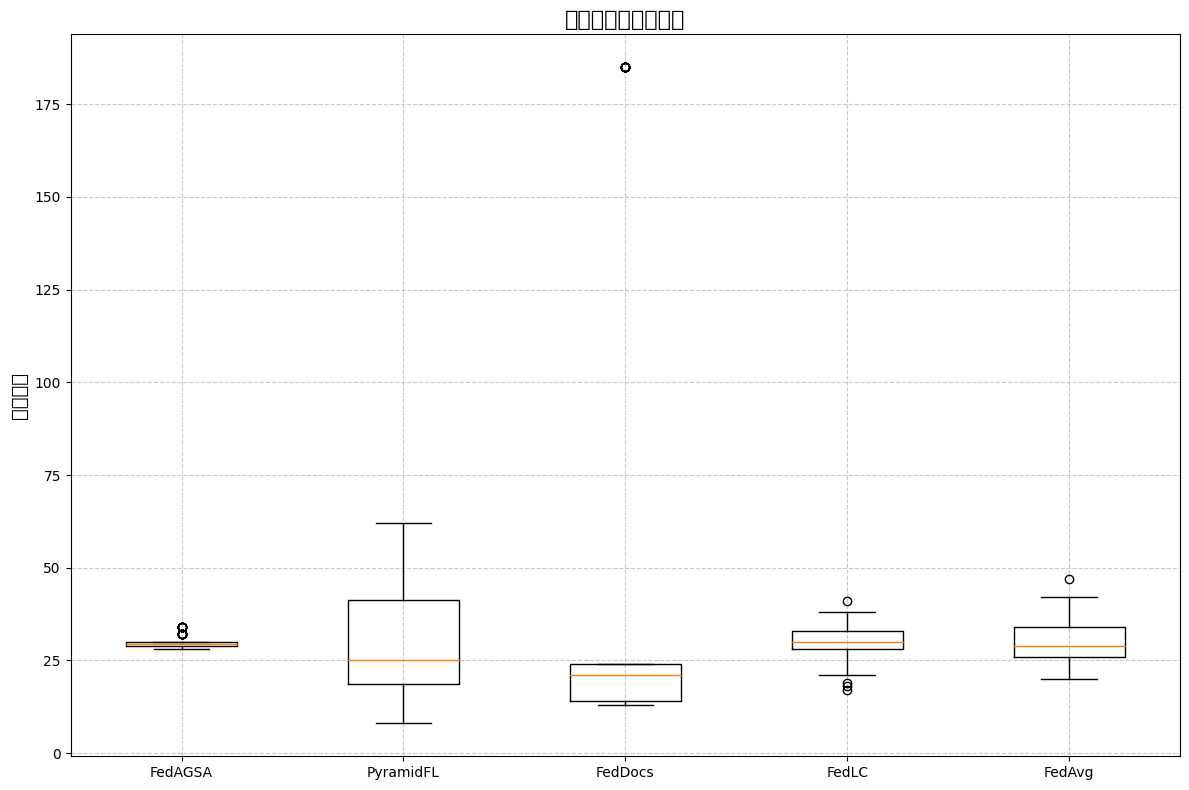

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31995 (\N{CJK UNIFIED I

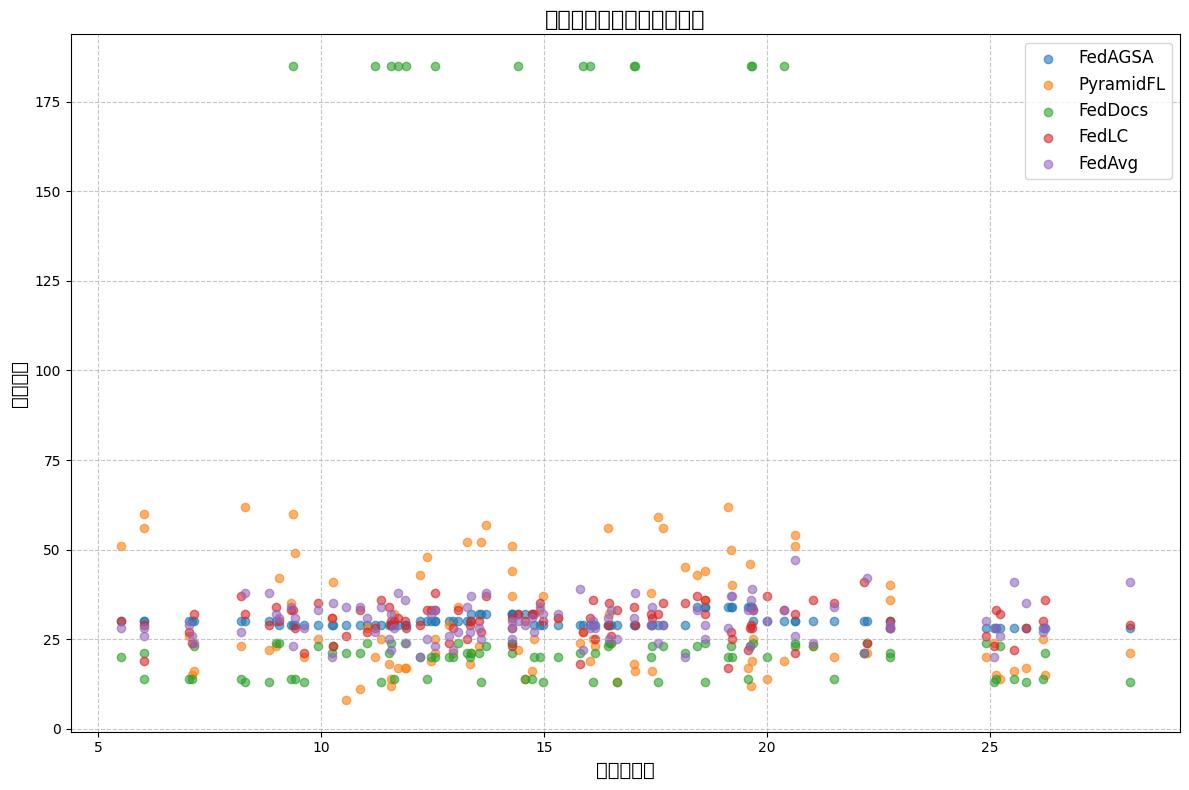

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


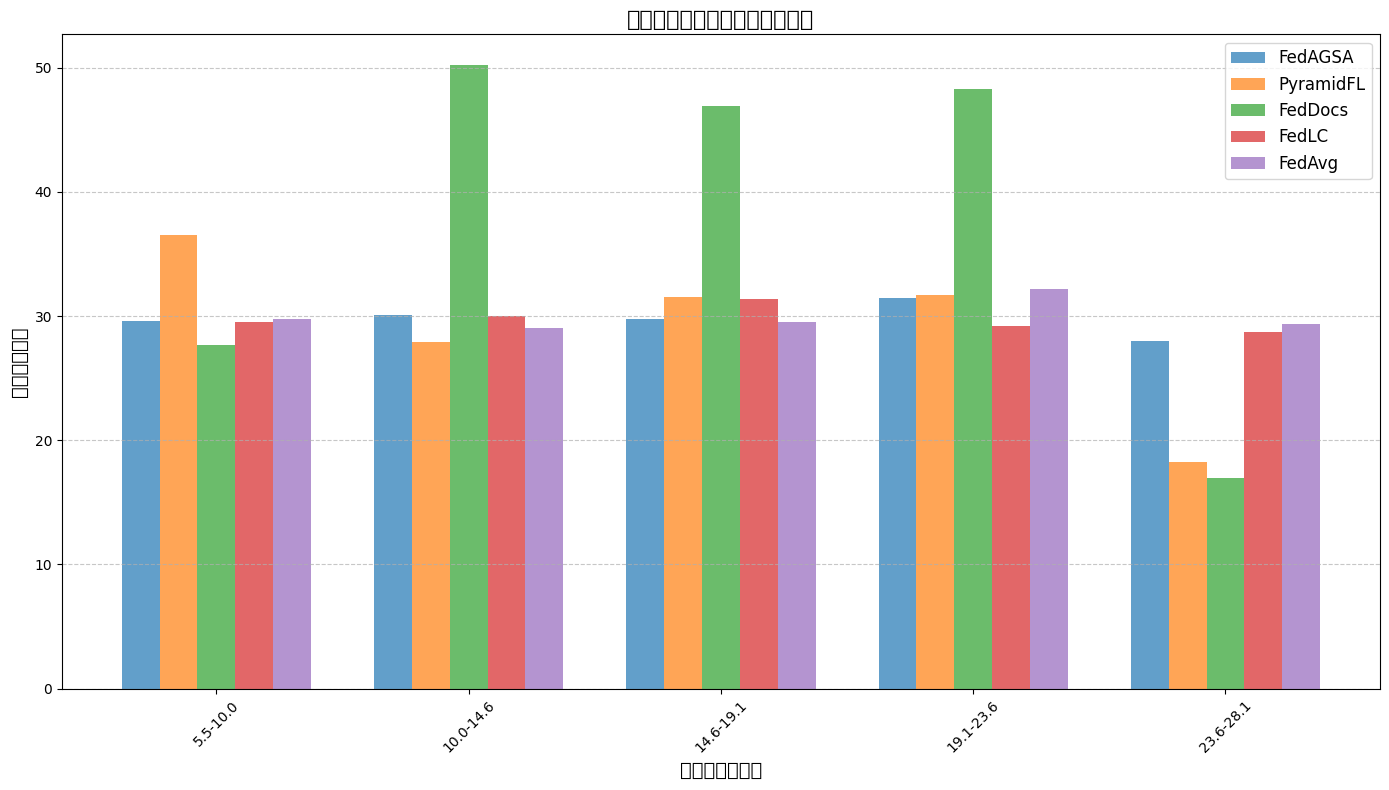

/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ypguo/.conda/envs/leofl/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65289 (\N{FULLWIDTH RIG

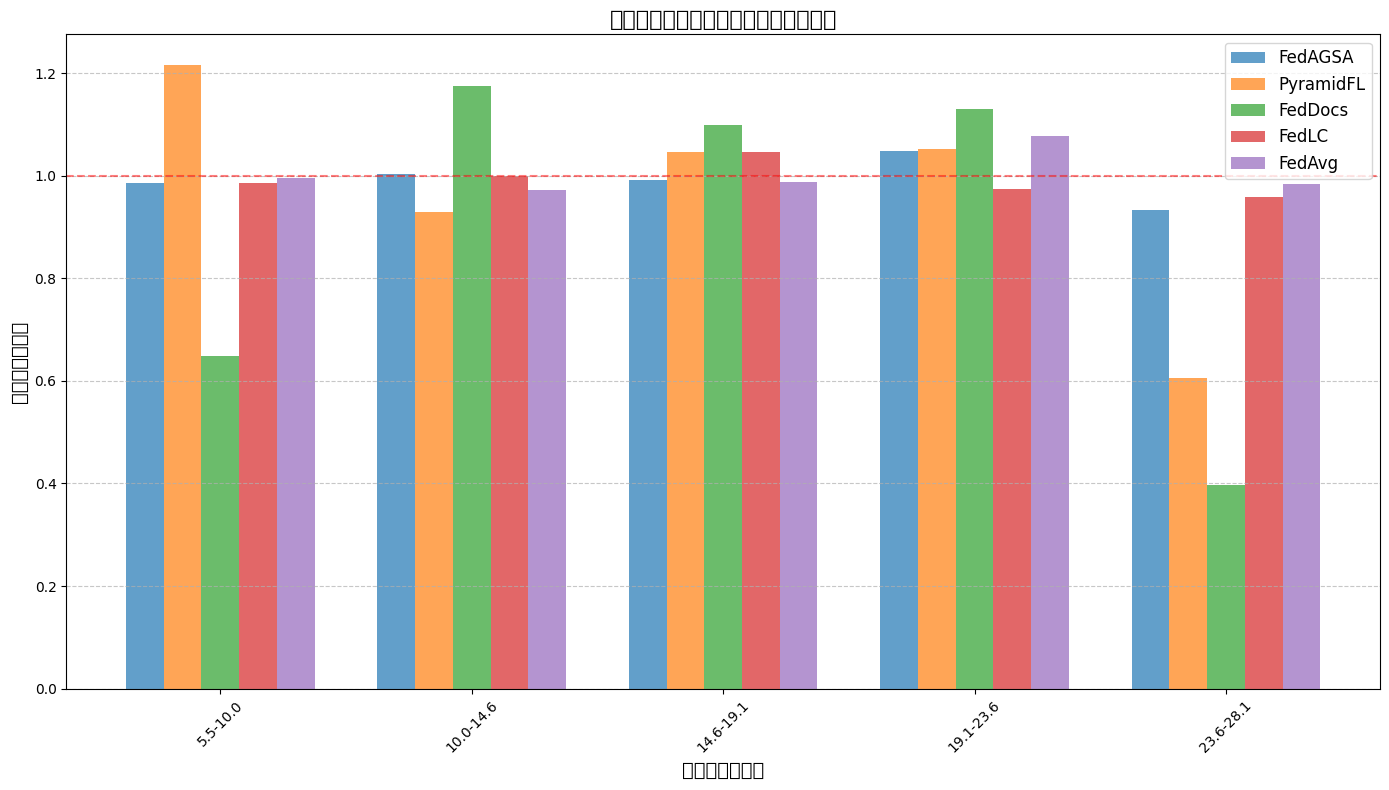

In [4]:
import os
# from analyze_client_selection import analyze_client_selection

def main():
    # 主实验目录路径
    main_dir = "/home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5"
    
    # 客户端时间信息文件路径
    time_info_file = "/home/ypguo/async-FL/src/clients_info/resnet18/clients_info_2class_resnet_delaymodel.csv"
    
    # 自定义时间区间（可以根据需要修改）
    # 如果不指定，将自动根据数据生成区间
    # time_bins = [0, 3, 6, 9, 12]
    
    # 限制分析的最大epoch数（可选）
    max_epoch = 300
    
    # 执行分析
    results = analyze_client_selection(
        main_dir=main_dir,
        time_info_file=time_info_file,
        # time_bins=time_bins,
        max_epoch=max_epoch,
        save_plots=True
    )
    
    # 输出每个算法的统计信息
    print("\n==== 各算法客户端选择统计 ====")
    for algo_name, result in results.items():
        print(f"\n算法: {algo_name}")
        print("时间区间统计:")
        print(result['bin_stats'])
        
        # 输出额外统计信息
        total_selections = sum(result['client_selections'].values())
        unique_clients = len(result['client_selections'])
        print(f"被选中的独立客户端数: {unique_clients}")
        print(f"客户端总选择次数: {total_selections}")
        print(f"平均每个客户端被选择次数: {total_selections/unique_clients:.2f}")

if __name__ == "__main__":
    main()